In [1]:
!pip install git+https://github.com/huggingface/transformers.git
!pip install accelerate

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-gdpvj4p1
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-gdpvj4p1
  Resolved https://github.com/huggingface/transformers.git to commit e2122c4bcb74d942bb93c11dcb55aafc4c7fdf23
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 13.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.1 MB/s eta 0:00:00:00:01
  Created wheel for transformers: filename=transformers-5.0.0.dev0-py3-none-any.whl size=11394600 sha256=6d6b614d57986e7ead10e30ff3468d92b8dff05364b21d5eb9ccf610f808b62b
  Stored in directory: /tmp/pip-ephem-wheel-cache-q7pyo4j5/wheels/32/4b/78/f195c684dd3a9ed21f3b39fe8f85b48df7918581b6437be143
Successfully built transformers
  Attempting uninstall: huggingface-hu

In [2]:
!pip install scikit-learn-extra umap-learn seaborn
!pip install gensim nltk textblob textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 93.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
import re
import os
import logging
import time
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from textblob import TextBlob
import textstat


In [5]:
class TrainingConfig:
    MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
    MAX_LEN = 256
    BATCH_SIZE = 64 # Increased batch size for faster embedding generation
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

# to load the full dataset for clustering
def load_full_data(config: TrainingConfig):
    logging.info("Loading full dataset for clustering analysis...")
    rows = []
    for filepath in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(filepath):
            logging.error(f"Data file not found at '{filepath}'.")
            return None
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line): rows.append(parsed)
    df = pd.DataFrame(rows)
    label_map = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2}
    df["label_id"] = df["label"].map(label_map)
    df = df.dropna(subset=['id', 'sent1', 'sent2', 'label_id', 'label'])
    logging.info(f"Full dataset loaded. Total samples: {len(df)}")
    return df.reset_index(drop=True)

class LegalDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df, self.tokenizer, self.max_len = df, tokenizer, max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sent1, sent2 = str(row["sent1"]), str(row["sent2"])
        encoded = self.tokenizer(sent1, sent2, padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        # For embedding, we only need input_ids and attention_mask
        return {"input_ids": encoded["input_ids"].squeeze(), "attention_mask": encoded["attention_mask"].squeeze()}

In [6]:
logger = logging.getLogger(__name__)


def generate_embeddings(df: pd.DataFrame, config: TrainingConfig):
    """Generates sentence-pair embeddings using LegalBERT."""
    logger.info(f"Loading model '{config.MODEL_NAME}' for embedding generation.")
    tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
    model = AutoModel.from_pretrained(config.MODEL_NAME).to(config.DEVICE)
    model.eval() # Set model to evaluation mode

    dataset = LegalDataset(df, tokenizer, config.MAX_LEN)
    data_loader = DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    all_embeddings = []
    logger.info("Generating embeddings...")
    with torch.no_grad(): # Disable gradient calculations for inference
        for batch in tqdm(data_loader, desc="Generating Embeddings"):
            input_ids = batch["input_ids"].to(config.DEVICE)
            attention_mask = batch["attention_mask"].to(config.DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # Use the [CLS] token's hidden state as the sentence-pair embedding
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

    embeddings = np.vstack(all_embeddings)
    logger.info(f"Embeddings generated with shape: {embeddings.shape}")
    return embeddings

# --- 1. Topic Modeling (LDA) ---

def preprocess_text_for_lda(text):
    """Tokenizes, removes stopwords/punctuation, and lemmatizes text."""
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    tokens = word_tokenize(text.lower())
    # Filter out stopwords, punctuation, and short tokens
    tokens = [
        lemmatizer.lemmatize(token) for token in tokens 
        if token.isalpha() and token not in stop_words and len(token) > 3
    ]
    return tokens

def perform_topic_modeling(df: pd.DataFrame, num_topics: int = 10):
    """Performs LDA Topic Modeling on the sentences in the DataFrame."""
    logger.info("Starting Topic Modeling (LDA)...")
    
    # Combine all sentences into a single list to model topics across the entire corpus
    all_sentences = pd.concat([df['sent1'], df['sent2']]).dropna().unique()
    processed_docs = [preprocess_text_for_lda(doc) for doc in all_sentences]
    
    # Create a dictionary and a corpus
    dictionary = Dictionary(processed_docs)
    dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100000)
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
    
    # Build the LDA model
    logger.info(f"Training LDA model with {num_topics} topics...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Print the topics
    print("\n--- LDA Topic Modeling Results ---")
    topics = lda_model.print_topics(num_words=10)
    for topic in topics:
        print(topic)
    print("---------------------------------")


# --- 2. Lexical Analysis ---

def perform_lexical_analysis(df: pd.DataFrame):
    """Performs and plots lexical analysis of the text data."""
    logger.info("Starting Lexical Analysis...")
    
    # Combine all sentences for a corpus-wide analysis
    all_text = " ".join(pd.concat([df['sent1'], df['sent2']]).dropna().unique())
    tokens = [token for token in word_tokenize(all_text.lower()) if token.isalpha()]

    # 2.1 Word Frequency Analysis
    word_counts = Counter(tokens)
    most_common_words = word_counts.most_common(20)
    
    print("\n--- Lexical Analysis Results ---")
    print("Top 20 Most Common Words:", most_common_words)
    
    # Plotting word frequencies
    plt.figure(figsize=(12, 8))
    sns.barplot(x=[word[1] for word in most_common_words], y=[word[0] for word in most_common_words])
    plt.title('Top 20 Most Common Words')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()

    # 2.2 Sentence Length Distribution
    df['sent1_len'] = df['sent1'].str.split().str.len()
    df['sent2_len'] = df['sent2'].str.split().str.len()
    
    plt.figure(figsize=(12, 6))
    sns.histplot(df['sent1_len'], color='blue', label='Sentence 1 Length', kde=True, bins=50)
    sns.histplot(df['sent2_len'], color='red', label='Sentence 2 Length', kde=True, bins=50)
    plt.title('Sentence Length Distribution')
    plt.xlabel('Number of Words')
    plt.legend()
    plt.xlim(0, 200) # Limiting x-axis for better visualization
    plt.show()
    
    # 2.3 Subjectivity and Readability (Bonus)
    # Note: This can be slow on the full dataset, so we use a sample
    sample_df = df.sample(n=1000, random_state=42)
    sample_df['sent1_subjectivity'] = sample_df['sent1'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
    sample_df['sent1_readability'] = sample_df['sent1'].apply(lambda x: textstat.flesch_reading_ease(str(x)))

    plt.figure(figsize=(12, 6))
    sns.histplot(sample_df['sent1_subjectivity'], color='purple', label='Subjectivity Score', kde=True)
    plt.title('Distribution of Subjectivity Scores (0=Objective, 1=Subjective)')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.histplot(sample_df['sent1_readability'], color='green', label='Flesch Reading Ease', kde=True)
    plt.title('Distribution of Readability Scores (Higher is easier)')
    plt.show()
    print("---------------------------------")


2025-10-15 11:16:29,533 - INFO - Using device: cpu
2025-10-15 11:16:32,651 - INFO - ========== STARTING TOPIC MODELING ANALYSIS ==========
2025-10-15 11:16:32,652 - INFO - Starting Topic Modeling (LDA)...
2025-10-15 11:16:59,928 - INFO - Training LDA model with 10 topics...
2025-10-15 11:18:14,680 - INFO - ========== STARTING LEXICAL ANALYSIS ==========
2025-10-15 11:18:14,681 - INFO - Starting Lexical Analysis...



--- LDA Topic Modeling Results ---
(0, '0.043*"judge" + 0.041*"even" + 0.037*"period" + 0.036*"special" + 0.031*"bench" + 0.028*"make" + 0.026*"offence" + 0.023*"three" + 0.022*"employee" + 0.021*"deceased"')
(1, '0.086*"appeal" + 0.036*"application" + 0.026*"passed" + 0.025*"amount" + 0.023*"clause" + 0.023*"dismissed" + 0.021*"decree" + 0.019*"circumstance" + 0.018*"account" + 0.015*"relevant"')
(2, '0.041*"property" + 0.039*"article" + 0.033*"india" + 0.029*"part" + 0.029*"interest" + 0.027*"claim" + 0.026*"respect" + 0.026*"entitled" + 0.025*"constitution" + 0.019*"payment"')
(3, '0.169*"court" + 0.079*"high" + 0.029*"judgment" + 0.027*"petition" + 0.027*"fact" + 0.022*"decision" + 0.021*"power" + 0.021*"view" + 0.019*"officer" + 0.018*"ground"')
(4, '0.058*"state" + 0.047*"rule" + 0.044*"government" + 0.042*"land" + 0.036*"provision" + 0.034*"shall" + 0.032*"person" + 0.027*"service" + 0.021*"civil" + 0.018*"possession"')
(5, '0.047*"suit" + 0.041*"evidence" + 0.024*"singh" + 0.0

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


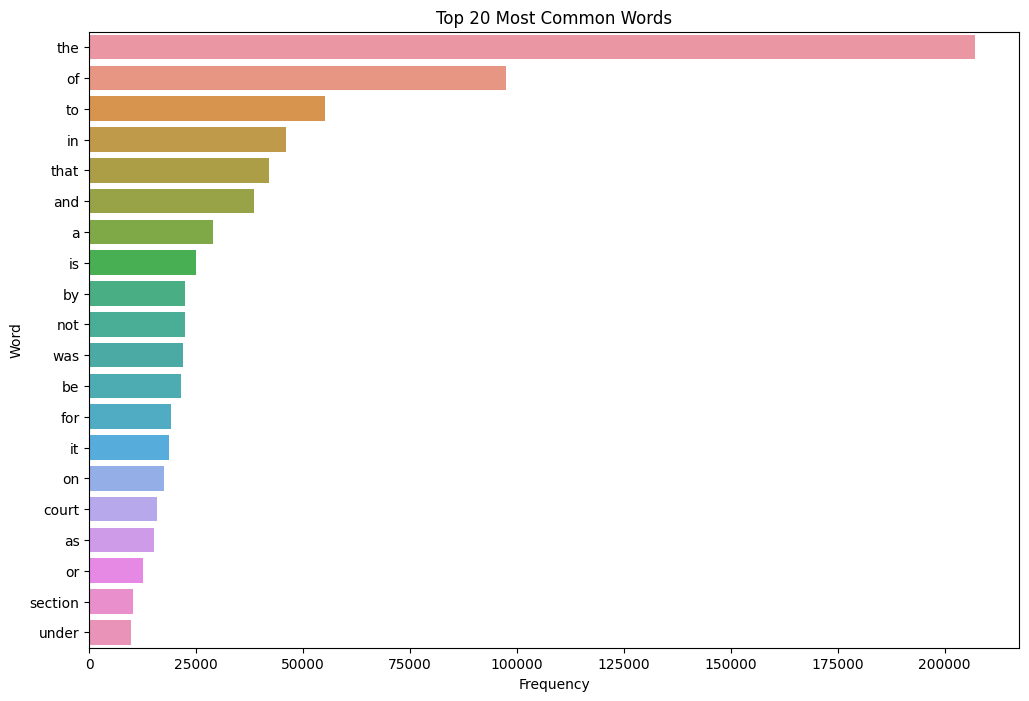

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


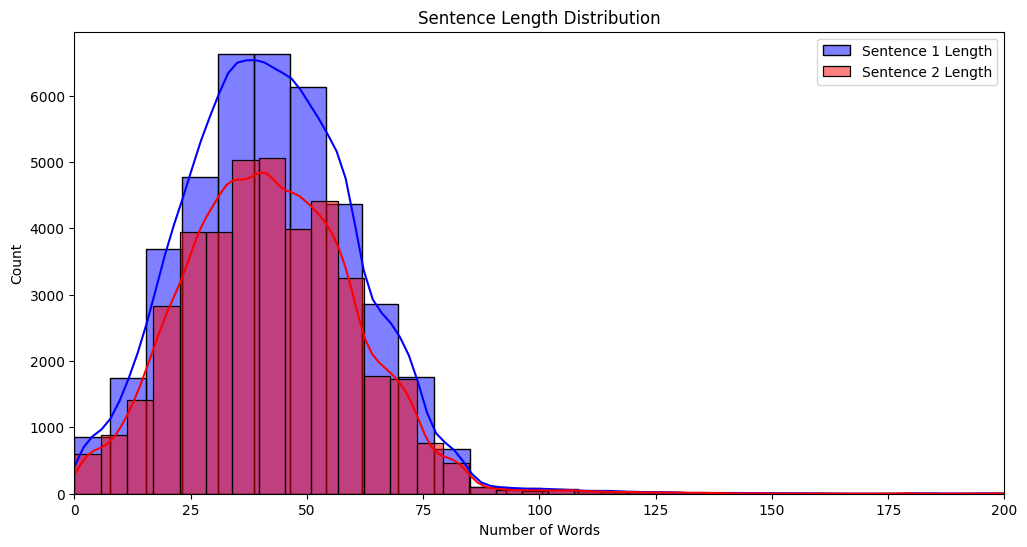

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


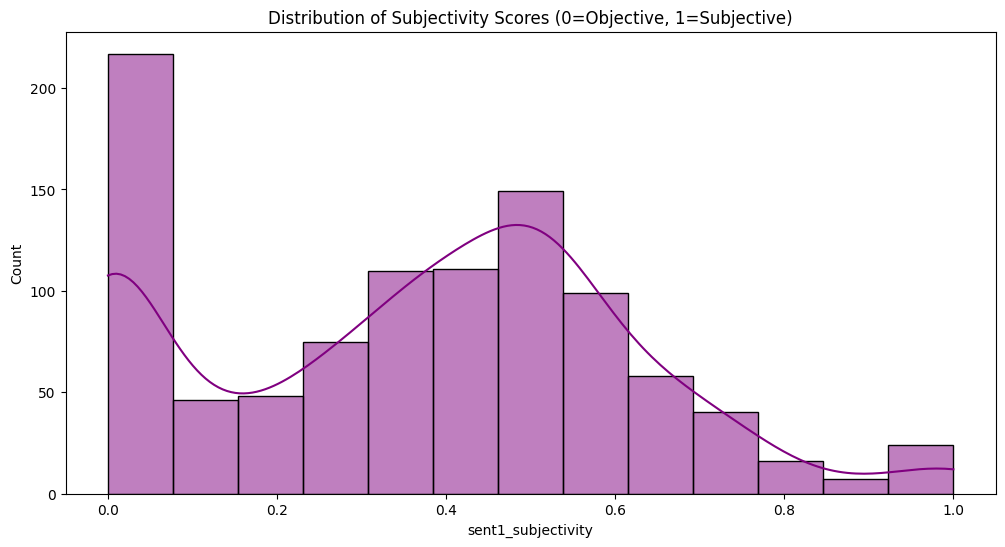

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


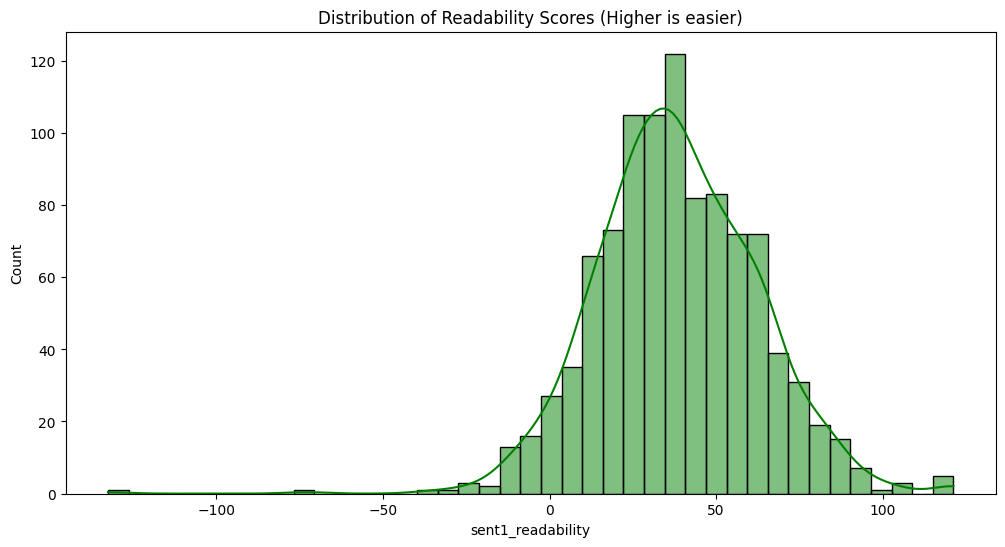

---------------------------------


In [7]:
# ==============================================================================
if __name__ == '__main__':
    config = TrainingConfig()
    # Setup logger
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    if not logger.handlers:
        file_handler = logging.FileHandler("data_analysis2.log")
        stream_handler = logging.StreamHandler()
        file_handler.setFormatter(formatter)
        stream_handler.setFormatter(formatter)
        logger.addHandler(file_handler)
        logger.addHandler(stream_handler)

    logger.info(f"Using device: {config.DEVICE}")

    # ---  ANALYSIS SECTION ---
    
    full_df = load_full_data(config)
    if full_df is not None:
        logger.info("========== STARTING TOPIC MODELING ANALYSIS ==========")
        perform_topic_modeling(full_df)
        logger.info("========== STARTING LEXICAL ANALYSIS ==========")
        perform_lexical_analysis(full_df)